## 📊 Анализ на цените на горивата (2020 – 2026)

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates

In [51]:
data = pd.read_csv('../datasets/fuelo_master_dataset.csv')
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year,start_date
0,1,30.12 - 05.01.20,1.14,1.17,0.49,2020,2020-12-30
1,2,06.01 - 12.01.20,1.14,1.17,0.49,2020,2020-01-06
2,3,13.01 - 19.01.20,1.14,1.17,0.49,2020,2020-01-13
3,4,20.01 - 26.01.20,1.14,1.17,0.50,2020,2020-01-20
4,5,27.01 - 02.02.20,1.14,1.17,0.50,2020,2020-01-27
...,...,...,...,...,...,...,...
316,4,19.01 - 25.01.26,1.24,1.26,0.59,2026,2026-01-19
317,5,26.01 - 01.02.26,1.24,1.26,0.57,2026,2026-01-26
318,6,02.02 - 08.02.26,1.24,1.26,0.58,2026,2026-02-02
319,7,09.02 - 15.02.26,1.24,1.26,0.58,2026,2026-02-09


In [52]:
data[["Бензин A95","Дизел", "Пропан Бутан"]].describe()

,Бензин A95,Дизел,Пропан Бутан
count,321.000000,321.000000,321.000000
mean,1.255701,1.284891,0.587819
std,0.198172,0.226390,0.098210
min,0.860000,0.880000,0.390000
25%,1.140000,1.160000,0.540000
50%,1.270000,1.270000,0.600000
75%,1.360000,1.410000,0.640000
max,1.750000,1.820000,0.820000


### 1️⃣ Колко е поскъпнал дизелът спрямо 2020 г.

Изчисляваме средната цена на дизела през 2020 г. и я сравняваме с текущата цена.
Това показва реалния процент на поскъпване за периода.

In [53]:
base_price = data[data["year"] == 2020]["Дизел"].mean()
current_price = data.iloc[-1]["Дизел"]

increase_pct = (current_price / base_price - 1) * 100

print(f"Дизелът е поскъпнал с {increase_pct:.1f}% спрямо 2020 г.")

Дизелът е поскъпнал с 29.3% спрямо 2020 г.


### 2️⃣ Най-скъпата седмица в периода

Откриваме седмицата с най-висока регистрирана цена на дизела.

👉 Това ни показва ценовия пик (най-скъпия момент за потребителите).

In [54]:
max_row = data.loc[data["Дизел"].idxmax()]

print("Най-скъпата седмица за дизела:")
print(max_row["Седмица"], "-", round(max_row["Дизел"], 2), "€")

Най-скъпата седмица за дизела:
27.06 - 03.07.22 - 1.82 €


### 3️⃣ Средна цена за текущата година

Изчисляваме средната цена за текущата година до момента.

👉 Позволява да сравним настоящата година с предходните.

In [55]:
current_year = data["year"].max()

avg_this_year = data[data["year"] == current_year][
    ["Бензин A95","Дизел","Пропан Бутан"]
].mean()

print(avg_this_year.round(2))

Бензин A95      1.30
Дизел           1.32
Пропан Бутан    0.61
dtype: float64


### 4️⃣ Колко струва пълен резервоар

Изчисляваме колко струва зареждане на 50 литра дизел при текущата цена.

👉 Това превежда цената в практическо измерение за шофьорите.

In [56]:
diesel_price = data.iloc[-1]["Дизел"]

tank_cost = diesel_price * 50

print(f"Пълен резервоар (50L дизел) струва {tank_cost:.2f} €")

Пълен резервоар (50L дизел) струва 63.00 €


### 5️⃣ Най-скъпата година

Изчисляваме средната цена по години и определяме коя година е била най-скъпа.

👉 Показва в коя година потребителите са плащали най-много средно.

In [57]:
yearly_avg = data.groupby("year")["Дизел"].mean()

most_expensive_year = yearly_avg.idxmax()

print("Най-скъпата година за дизела е:", most_expensive_year)

Най-скъпата година за дизела е: 2022


## 🚗 1️⃣ Колко струва горивото за една година

Изчисляваме приблизителен годишен разход при:

- 15 000 км годишно
- Разход: 7 л / 100 км
- Използваме средната цена за последната година

Това показва реалния годишен бюджет за гориво.

In [58]:
annual_km = 15000
consumption = 7  # литра на 100 км

current_year = data["year"].max()

avg_price = data[data["year"] == current_year]["Дизел"].mean()

liters_per_year = (annual_km / 100) * consumption
annual_cost = liters_per_year * avg_price

print(f"Годишен разход за гориво: {annual_cost:.2f} €")

Годишен разход за гориво: 1389.94 €


## ⛽ 2️⃣ Колко спестяваме с LPG вместо дизел

Сравняваме цената на 50 литра дизел и 50 литра пропан-бутан.

Това показва директната икономия при едно зареждане.

In [59]:
latest = data.iloc[-1]

diesel_cost = latest["Дизел"] * 50
lpg_cost = latest["Пропан Бутан"] * 50

savings = diesel_cost - lpg_cost

print(f"Икономия при 50L: {savings:.2f} €")

Икономия при 50L: 34.00 €


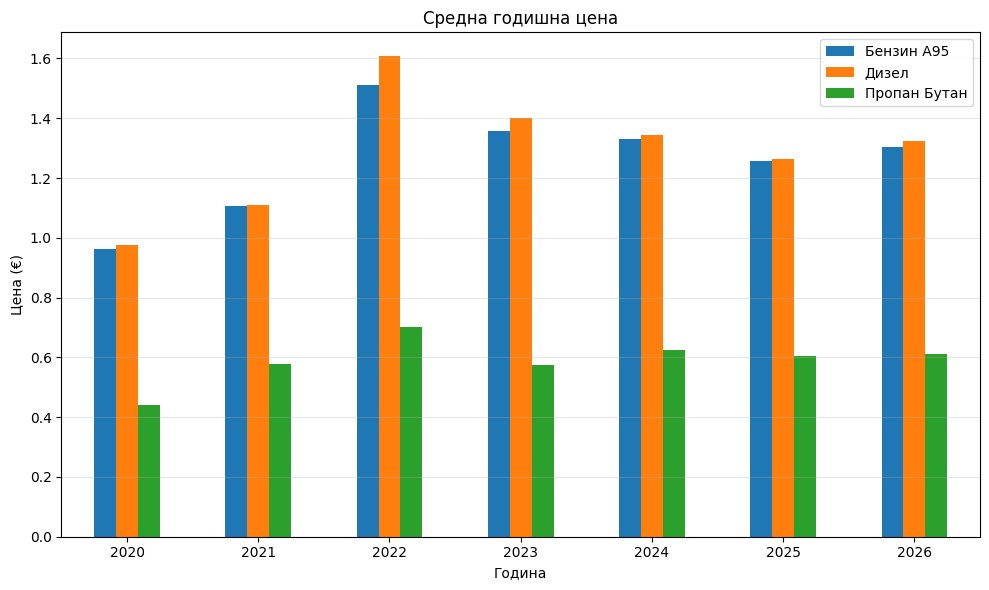

In [60]:
yearly_avg = data.groupby("year")[
    ["Бензин A95","Дизел","Пропан Бутан"]
].mean()

yearly_avg.plot(kind="bar", figsize=(10,6))

plt.title("Средна годишна цена")
plt.ylabel("Цена (€)")
plt.xlabel("Година")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

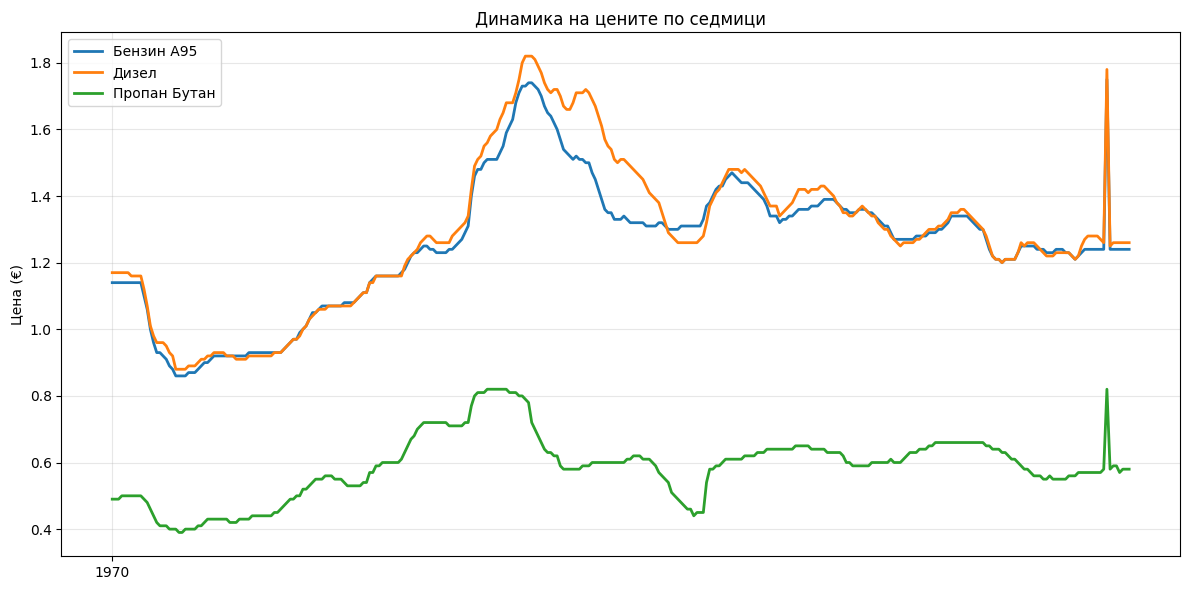

In [61]:
fig, ax = plt.subplots(figsize=(12,6))

for col in ["Бензин A95","Дизел","Пропан Бутан"]:
    ax.plot(data["start_date"], data[col], linewidth=2, label=col)

# 👉 Показваме само години
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Динамика на цените по седмици")
plt.ylabel("Цена (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

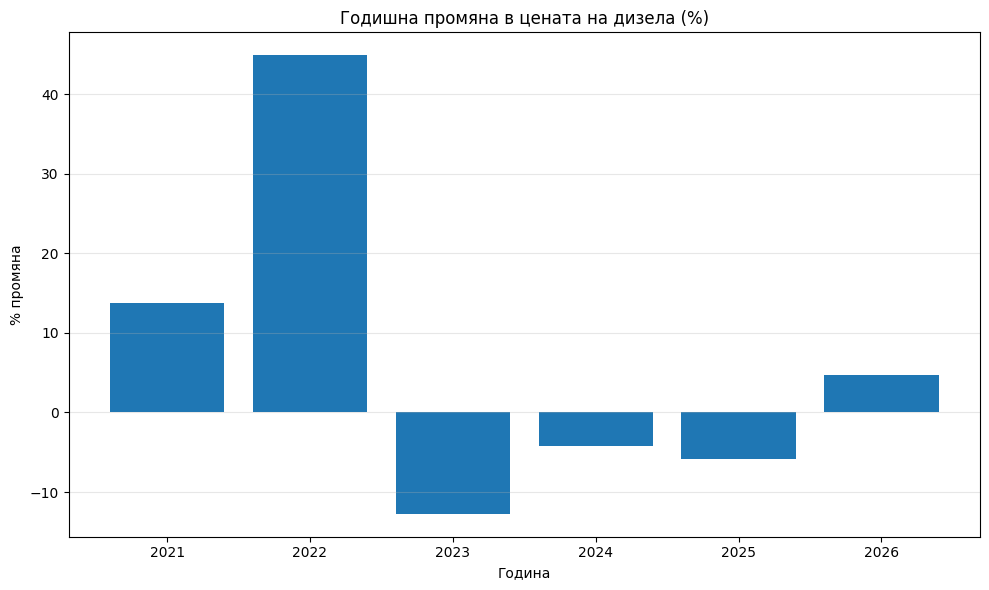

In [63]:
yearly_avg = data.groupby("year")["Дизел"].mean()
yoy = yearly_avg.pct_change() * 100

plt.figure(figsize=(10,6))
plt.bar(yoy.index, yoy.values)

plt.title("Годишна промяна в цената на дизела (%)")
plt.xlabel("Година")
plt.ylabel("% промяна")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

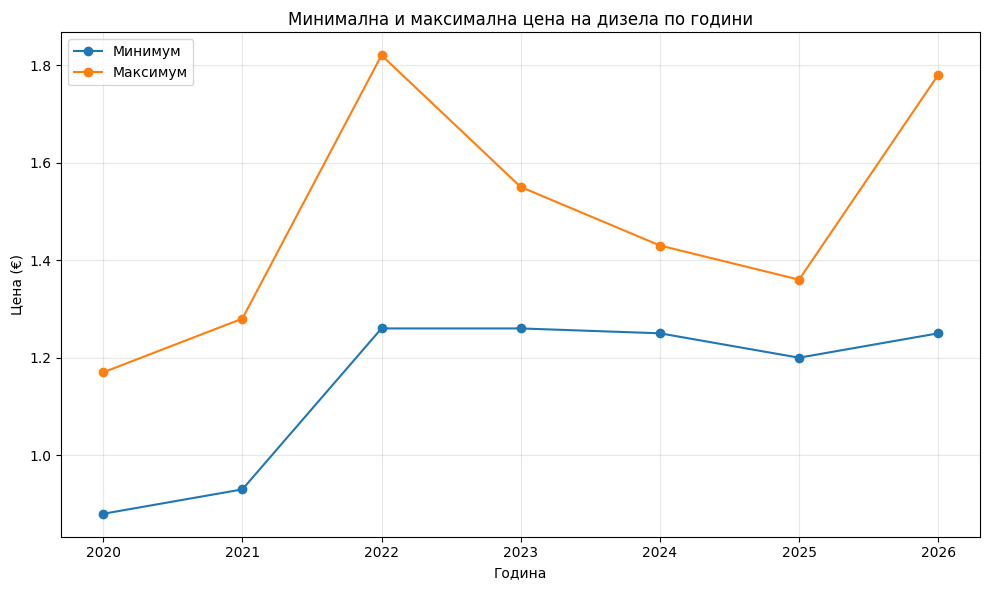

In [64]:
yearly_min = data.groupby("year")["Дизел"].min()
yearly_max = data.groupby("year")["Дизел"].max()

plt.figure(figsize=(10,6))

plt.plot(yearly_min.index, yearly_min.values, marker="o", label="Минимум")
plt.plot(yearly_max.index, yearly_max.values, marker="o", label="Максимум")

plt.title("Минимална и максимална цена на дизела по години")
plt.xlabel("Година")
plt.ylabel("Цена (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()